[Reference](https://medium.com/@Rohan_Dutt/10-forecasting-techniques-used-in-finance-retail-and-manufacturing-kpis-e74ea0dd79f4$0)

# 1. Bayesian Forecasting: Update Predictions Like a Machine

Output()

Prior mean demand: 200 units
Posterior mean demand: 199.4 units
Updated forecast after 3 new days: 203.8 units
95% Credible Interval: 176.0 - 234.0 units


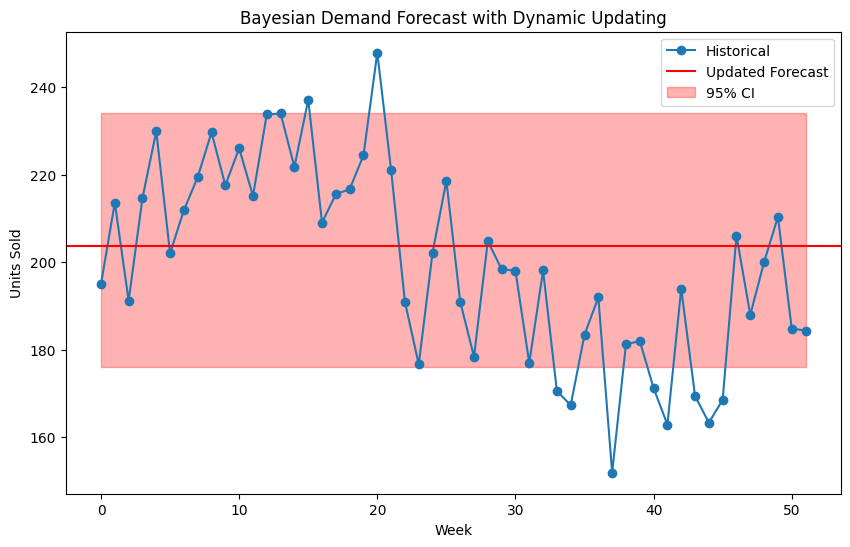

In [1]:
import pymc as pm
import pandas as pd
import numpy as np

# Historical weekly demand data (52 weeks)
np.random.seed(42)
historical_demand = np.random.poisson(lam=200, size=52) + np.sin(np.arange(52) * 2 * np.pi / 52) * 30
# New partial week data
new_data = [205, 198, 210]
# Bayesian model
with pm.Model() as demand_model:
    # Prior: belief about average demand
    lambda_prior = pm.Gamma('lambda', alpha=200, beta=1)

    # Likelihood: observed data
    demand_obs = pm.Poisson('demand', mu=lambda_prior, observed=historical_demand)

    # Posterior sampling
    trace = pm.sample(2000, chains=2, cores=1, return_inferencedata=False)

    # Update with new data
    lambda_posterior = trace['lambda']
    updated_posterior = np.random.poisson(lam=lambda_posterior.mean() + np.mean(new_data) - 200, size=5000)
print(f"Prior mean demand: 200 units")
print(f"Posterior mean demand: {np.mean(lambda_posterior):.1f} units")
print(f"Updated forecast after 3 new days: {np.mean(updated_posterior):.1f} units")
print(f"95% Credible Interval: {np.percentile(updated_posterior, 2.5):.1f} - {np.percentile(updated_posterior, 97.5):.1f} units")
# Visualize updating
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(historical_demand, label='Historical', marker='o')
plt.axhline(y=np.mean(updated_posterior), color='r', linestyle='-', label='Updated Forecast')
plt.fill_between(x=range(52),
                y1=np.percentile(updated_posterior, 2.5),
                y2=np.percentile(updated_posterior, 97.5),
                alpha=0.3, color='red', label='95% CI')
plt.title("Bayesian Demand Forecast with Dynamic Updating")
plt.xlabel("Week")
plt.ylabel("Units Sold")
plt.legend()
plt.show()

# 2. Monte Carlo Simulation: Stress-Test Your Assumptions

Mean revenue: $224,891
95% Confidence Interval: $124,522 - $358,422
Probability of hitting $2M target: 0.0%


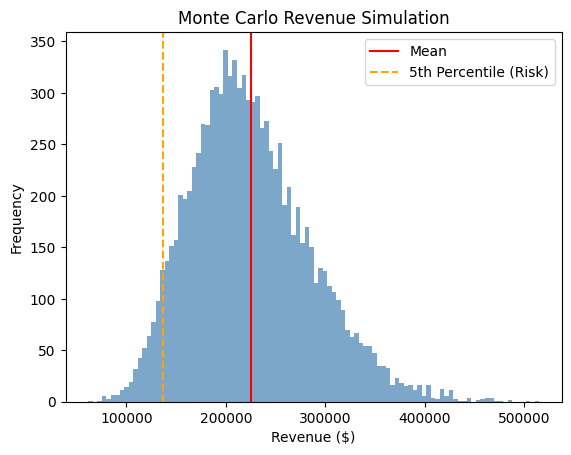

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Define distributions based on historical data
traffic_mean, traffic_std = 50000, 5000  # monthly site traffic
conversion_alpha, conversion_beta = 30, 970  # 3% rate from 1000 trials
aov_mean, aov_std = 150, 25  # average order value

# Run 10000 simulations
np.random.seed(42)
n_simulations = 10000
traffic = np.random.normal(traffic_mean, traffic_std, n_simulations)
conversion_rate = np.random.beta(conversion_alpha, conversion_beta, n_simulations)
aov = np.random.normal(aov_mean, aov_std, n_simulations)

# Calculate revenue
revenue = traffic * conversion_rate * aov

# Analyze results
print(f"Mean revenue: ${revenue.mean():,.0f}")
print(f"95% Confidence Interval: ${np.percentile(revenue, 2.5):,.0f} - ${np.percentile(revenue, 97.5):,.0f}")
print(f"Probability of hitting $2M target: {np.mean(revenue > 2000000):.1%}")

# Visualize
plt.hist(revenue, bins=100, alpha=0.7, color='steelblue')
plt.axvline(revenue.mean(), color='red', linestyle='-', label='Mean')
plt.axvline(np.percentile(revenue, 5), color='orange', linestyle='--', label='5th Percentile (Risk)')
plt.title("Monte Carlo Revenue Simulation")
plt.xlabel("Revenue ($)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# 3. Causal Impact Analysis (Google’s Secret Weapon)

In [3]:
import pandas as pd
import numpy as np
from causalimpact import CausalImpact
import matplotlib.pyplot as plt

# Create time series: 100 days of daily sales
np.random.seed(42)
date_range = pd.date_range(start='2024-01-01', periods=100)
baseline_sales = 5000 + np.cumsum(np.random.normal(0, 50, 100)) + np.sin(np.arange(100) * 2 * np.pi / 7) * 200

# Control market sales (similar pattern, no campaign)
control_sales = 4800 + np.cumsum(np.random.normal(0, 45, 100)) + np.sin(np.arange(100) * 2 * np.pi / 7) * 180

# Introduce campaign on day 70 in test market
campaign_effect = np.where(np.arange(100) >= 70, 800, 0)
test_sales = baseline_sales + campaign_effect + np.random.normal(0, 30, 100)

# Prepare data for CausalImpact
data = pd.DataFrame({
    'test_market': test_sales,
    'control_market': control_sales
}, index=date_range)

# Pre-intervention period: days 0-69, Post-intervention: days 70-99
pre_period = [data.index[0], data.index[69]]
post_period = [data.index[70], data.index[-1]]

# Run analysis
ci = CausalImpact(data, pre_period, post_period)

# Print summary
print(ci.summary())
print("\nDetailed results:")
print(ci.summary('report'))

# Visualize
ci.plot()
plt.show()

ModuleNotFoundError: No module named 'causalimpact'

# 4. Ensemble Forecasting: Outpredict Any Single Model


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# Generate synthetic revenue data (200 days)
np.random.seed(42)
dates = pd.date_range(start='2023-01-01', periods=200)
trend = np.linspace(100, 150, 200)
seasonality = 10 * np.sin(np.arange(200) * 2 * np.pi / 30)
noise = np.random.normal(0, 5, 200)
revenue = trend + seasonality + noise

df = pd.DataFrame({'date': dates, 'revenue': revenue})
df.set_index('date', inplace=True)

# Train-test split
train = df.iloc[:150]
test = df.iloc[150:]

# 1. ARIMA model
arima_model = SARIMAX(train['revenue'], order=(2,1,2), seasonal_order=(1,1,1,30))
arima_fitted = arima_model.fit(disp=False)
arima_pred = arima_fitted.forecast(steps=50)

# 2. XGBoost features
def create_features(data, lag=5):
    df = data.copy()
    for i in range(1, lag+1):
        df[f'lag_{i}'] = df['revenue'].shift(i)
    df['rolling_mean'] = df['revenue'].rolling(window=5).mean()
    df['rolling_std'] = df['revenue'].rolling(window=5).std()
    return df.dropna()

train_features = create_features(train)
X_train = train_features.drop('revenue', axis=1)
y_train = train_features['revenue']

test_features = create_features(df.iloc[130:])  # Include lags from train tail
X_test = test_features.drop('revenue', axis=1).iloc[-50:]

xgb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

# 3. Simple average ensemble
ensemble_pred = (arima_pred.values + xgb_pred) / 2

# Evaluate
arima_mae = mean_absolute_error(test['revenue'], arima_pred)
xgb_mae = mean_absolute_error(test['revenue'], xgb_pred)
ensemble_mae = mean_absolute_error(test['revenue'], ensemble_pred)

print(f"ARIMA MAE: ${arima_mae:.2f}")
print(f"XGBoost MAE: ${xgb_mae:.2f}")
print(f"Ensemble MAE: ${ensemble_mae:.2f}")
print(f"Ensemble improvement: {((min(arima_mae, xgb_mae) - ensemble_mae) / min(arima_mae, xgb_mae) * 100):.1f}%")

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['revenue'], label='Actual', color='black')
plt.plot(test.index, arima_pred, label='ARIMA', alpha=0.7)
plt.plot(test.index, xgb_pred, label='XGBoost', alpha=0.7)
plt.plot(test.index, ensemble_pred, label='Ensemble', linewidth=2, color='red')
plt.title("Ensemble Forecast: ARIMA + XGBoost")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.show()

# 5. Scenario Planning: Play Chess Against the Future


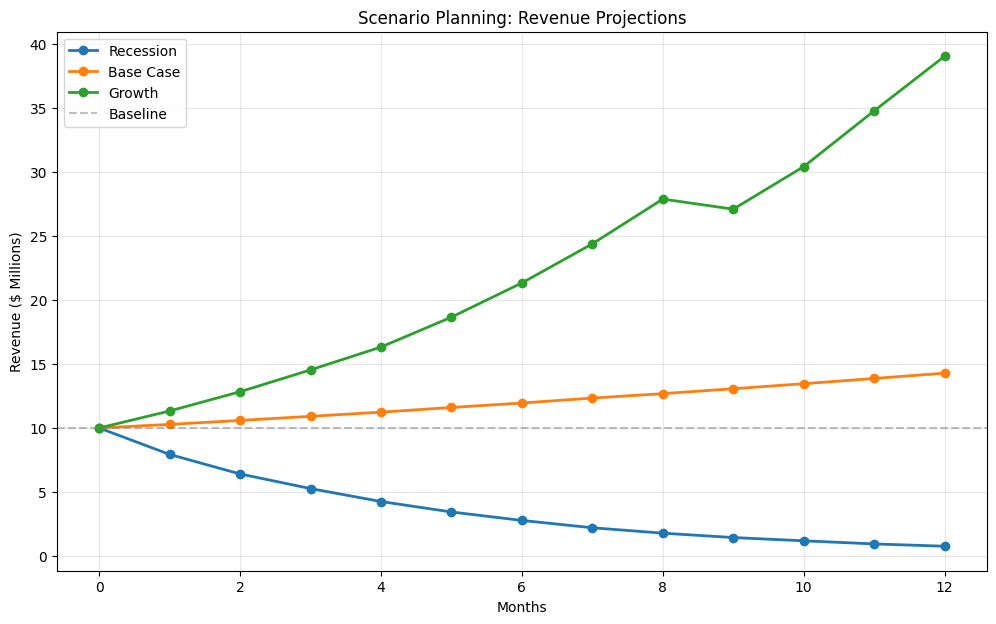


Action Triggers:
Recession scenario Month 6: $2.8M
Growth scenario Month 6: $21.3M
If actual revenue drops below $9.5M by Month 3, activate contingency plan.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Base parameters
current_revenue = 10_000_000
months = 12

# Define three scenarios
scenarios = {
    'Recession': {
        'demand_change': -0.15,
        'price_change': -0.05,
        'supply_disruption': 0.10,
        'probabilities': [0.3, 0.5, 0.2]  # Prob of worsening each month
    },
    'Base Case': {
        'demand_change': 0.02,
        'price_change': 0.01,
        'supply_disruption': 0.02,
        'probabilities': [0.1, 0.7, 0.2]
    },
    'Growth': {
        'demand_change': 0.10,
        'price_change': 0.03,
        'supply_disruption': 0.01,
        'probabilities': [0.1, 0.3, 0.6]
    }
}

results = {}
for name, params in scenarios.items():
    monthly_revenue = [current_revenue]
    revenue = current_revenue

    for month in range(1, months + 1):
        # Monte Carlo within each scenario
        demand_shock = np.random.choice([0.9, 1.0, 1.1], p=params['probabilities'])
        supply_penalty = 1 - np.random.binomial(1, params['supply_disruption']) * 0.15

        revenue = revenue * (1 + params['demand_change'] * demand_shock) * \
                  (1 + params['price_change']) * supply_penalty
        monthly_revenue.append(revenue)

    results[name] = monthly_revenue

# Create DataFrame and plot
df_results = pd.DataFrame(results, index=range(0, months+1))
df_results.index.name = 'Month'

plt.figure(figsize=(12, 7))
for scenario in scenarios.keys():
    plt.plot(df_results.index, df_results[scenario]/1_000_000,
             marker='o', linewidth=2, label=scenario)

plt.axhline(y=10, color='gray', linestyle='--', alpha=0.5, label='Baseline')
plt.title("Scenario Planning: Revenue Projections")
plt.xlabel("Months")
plt.ylabel("Revenue ($ Millions)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print trigger thresholds
print("\nAction Triggers:")
print(f"Recession scenario Month 6: ${df_results.loc[6, 'Recession']/1_000_000:.1f}M")
print(f"Growth scenario Month 6: ${df_results.loc[6, 'Growth']/1_000_000:.1f}M")
print("If actual revenue drops below $9.5M by Month 3, activate contingency plan.")

# 6. Top-Down & Bottom-Up Reconciliation

Bottom-up total: $4,145,000
Top-down target: $3,500,000
Gap: $-645,000

Reconciled Forecast:
  product  unit_forecast  reconciled_units  reconciled_revenue
0       A          10000       7060.759494        3.530380e+05
1       B          15000      13475.949367        1.010696e+06
2       C           8000       6693.670886        6.693671e+05
3       D          12000      10367.088608        6.220253e+05
4       E           5000       4224.367089        8.448734e+05

Reconciled total: $3,500,000
Difference from target: $0


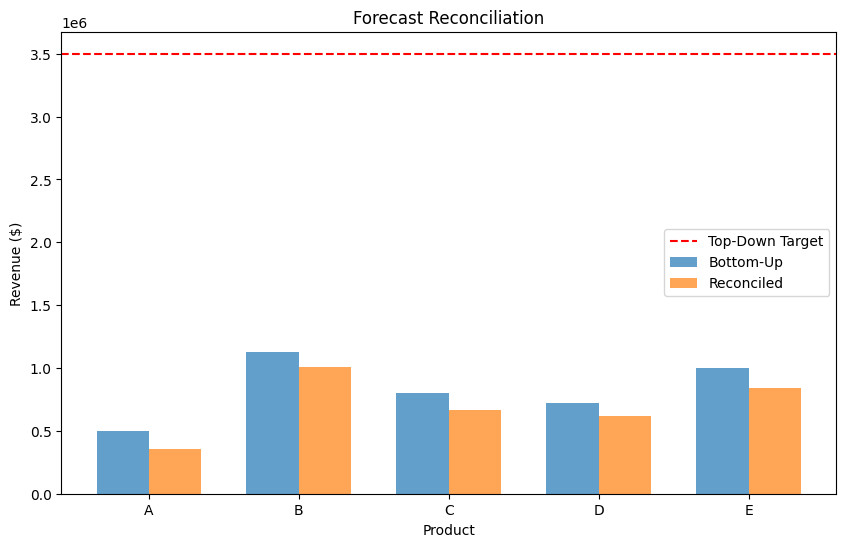

In [5]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize

# Bottom-up forecasts from 5 product lines
product_data = {
    'product': ['A', 'B', 'C', 'D', 'E'],
    'unit_forecast': [10000, 15000, 8000, 12000, 5000],
    'price': [50, 75, 100, 60, 200],
    'confidence': [0.9, 0.7, 0.8, 0.6, 0.95]  # Team confidence scores
}

df_products = pd.DataFrame(product_data)
df_products['revenue_forecast'] = df_products['unit_forecast'] * df_products['price']

# Top-down target from finance
top_down_target = 3_500_000  # $3.5M

# Current bottom-up total
bottom_up_total = df_products['revenue_forecast'].sum()
print(f"Bottom-up total: ${bottom_up_total:,.0f}")
print(f"Top-down target: ${top_down_target:,.0f}")
print(f"Gap: ${top_down_target - bottom_up_total:,.0f}")

# Reconciliation: Weighted adjustment based on confidence
total_confidence = df_products['confidence'].sum()
df_products['weight'] = df_products['confidence'] / total_confidence

# Distribute the gap proportionally
gap = top_down_target - bottom_up_total
df_products['adjustment'] = (df_products['weight'] * gap) / df_products['price']
df_products['reconciled_units'] = df_products['unit_forecast'] + df_products['adjustment']
df_products['reconciled_revenue'] = df_products['reconciled_units'] * df_products['price']

# Verify
print("\nReconciled Forecast:")
print(df_products[['product', 'unit_forecast', 'reconciled_units', 'reconciled_revenue']])
print(f"\nReconciled total: ${df_products['reconciled_revenue'].sum():,.0f}")
print(f"Difference from target: ${top_down_target - df_products['reconciled_revenue'].sum():,.0f}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(df_products))
width = 0.35
ax.bar(x - width/2, df_products['revenue_forecast'], width, label='Bottom-Up', alpha=0.7)
ax.bar(x + width/2, df_products['reconciled_revenue'], width, label='Reconciled', alpha=0.7)
ax.axhline(y=top_down_target, color='red', linestyle='--', label='Top-Down Target')
ax.set_xlabel('Product')
ax.set_ylabel('Revenue ($)')
ax.set_title('Forecast Reconciliation')
ax.set_xticks(x)
ax.set_xticklabels(df_products['product'])
ax.legend()
plt.show()

# 7. Predictive Lead Scoring (B2B’s Hidden Gem)


In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Create synthetic lead data
np.random.seed(42)
n_leads = 1000

data = {
    'company_size': np.random.choice(['small', 'medium', 'large'], n_leads, p=[0.5, 0.3, 0.2]),
    'industry_score': np.random.randint(1, 10, n_leads),
    'website_visits': np.random.poisson(5, n_leads),
    'whitepaper_downloads': np.random.poisson(2, n_leads),
    'demo_requests': np.random.poisson(1, n_leads),
    'days_since_contact': np.random.exponential(30, n_leads).astype(int),
    'deal_size': np.random.lognormal(12, 1.5, n_leads)
}

df = pd.DataFrame(data)
df['converted'] = (
    (df['industry_score'] > 7) * 0.3 +
    (df['demo_requests'] > 0) * 0.4 +
    (df['website_visits'] > 8) * 0.2 +
    (df['company_size'] == 'large') * 0.2 +
    np.random.normal(0, 0.3, n_leads)
) > 0.5

# Encode categoricals
df_encoded = pd.get_dummies(df, columns=['company_size'], drop_first=True)

# Features and target
features = [col for col in df_encoded.columns if col != 'converted']
X = df_encoded[features]
y = df_encoded['converted']

# Split and train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)

# Predict and score
df_encoded['lead_score'] = model.predict_proba(X)[:, 1]

# Evaluate
print("Model Performance:")
print(classification_report(y_test, model.predict(X_test)))
print(f"ROC-AUC: {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]):.3f}")

# Pipeline forecast
pipeline_value = (df_encoded['lead_score'] * df_encoded['deal_size']).sum()
expected_conversion = (df_encoded['lead_score'] * df_encoded['deal_size'] *
                      df_encoded['converted']).sum() / pipeline_value

print(f"\nPipeline Forecast:")
print(f"Total pipeline value: ${pipeline_value:,.0f}")
print(f"Expected conversion rate: {expected_conversion:.1%}")
print(f"Forecasted revenue: ${pipeline_value * expected_conversion:,.0f}")

# Segment analysis
df_encoded['tier'] = pd.cut(df_encoded['lead_score'], bins=[0, 0.3, 0.7, 1.0],
                           labels=['Cold', 'Warm', 'Hot'])
print("\nRevenue by Tier:")
print(df_encoded.groupby('tier').apply(lambda x: (x['lead_score'] * x['deal_size']).sum()))

Model Performance:
              precision    recall  f1-score   support

       False       0.70      0.93      0.80       122
        True       0.77      0.38      0.51        78

    accuracy                           0.71       200
   macro avg       0.74      0.66      0.66       200
weighted avg       0.73      0.71      0.69       200

ROC-AUC: 0.807

Pipeline Forecast:
Total pipeline value: $194,724,945
Expected conversion rate: 52.3%
Forecasted revenue: $101,858,647

Revenue by Tier:
tier
Cold    2.218597e+07
Warm    1.304501e+08
Hot     4.208884e+07
dtype: float64


/tmp/ipykernel_770/578006589.py:66: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_encoded.groupby('tier').apply(lambda x: (x['lead_score'] * x['deal_size']).sum()))
/tmp/ipykernel_770/578006589.py:66: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(df_encoded.groupby('tier').apply(lambda x: (x['lead_score'] * x['deal_size']).sum()))


# 8. Nowcasting: Delegate Forecasting to Stakeholders


/tmp/ipykernel_770/3635109331.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df = pd.DataFrame(forecasts, index=pd.date_range('2024-01', periods=6, freq='M'))


Department Weights (based on historical accuracy):
sales: 44.44%
operations: 30.71%
finance: 24.85%

Nowcast Results:
            sales  operations  finance     nowcast  lower_bound  upper_bound
month                                                                       
2024-01-31    105         102      100  102.836158   100.319546   105.352769
2024-02-29    108         104      103  105.529058   102.883307   108.174809
2024-03-31    110         106      107  108.026075   105.944409   110.107741
2024-04-30    112         108      111  110.523092   108.441426   112.604758
2024-05-31    115         109      114  112.908892   109.694342   116.123442
2024-06-30    118         110      117  115.294692   110.935793   119.653591
sales MAPE: 2.9%, Bonus multiplier: 0.67x
operations MAPE: 4.0%, Bonus multiplier: 0.46x
finance MAPE: 3.7%, Bonus multiplier: 0.37x


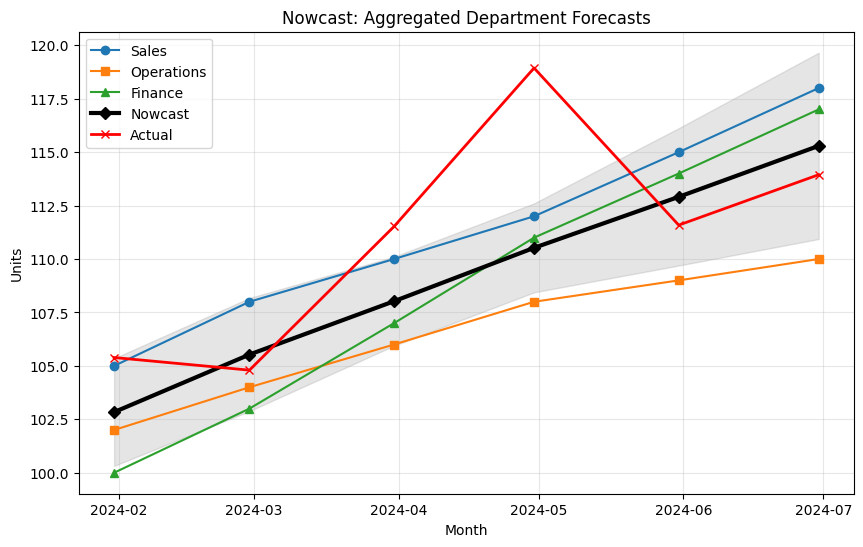

In [7]:
import pandas as pd
import numpy as np

# Three departments submit monthly forecasts for 6 months
forecasts = {
    'sales': [105, 108, 110, 112, 115, 118],
    'operations': [102, 104, 106, 108, 109, 110],
    'finance': [100, 103, 107, 111, 114, 117]
}

# Historical forecast accuracy (lower MAPE = better)
accuracy_scores = {
    'sales': 8.5,  # MAPE 8.5%
    'operations': 12.3,
    'finance': 15.2
}

df = pd.DataFrame(forecasts, index=pd.date_range('2024-01', periods=6, freq='M'))
df.index.name = 'month'

# Calculate weights (inverse of MAPE)
weights = {dept: 1/score for dept, score in accuracy_scores.items()}
total_weight = sum(weights.values())
normalized_weights = {dept: w/total_weight for dept, w in weights.items()}

print("Department Weights (based on historical accuracy):")
for dept, weight in normalized_weights.items():
    print(f"{dept}: {weight:.2%}")

# Weighted nowcast
df['nowcast'] = sum(df[dept] * normalized_weights[dept] for dept in forecasts.keys())

# Add uncertainty bounds (based on dispersion)
df['spread'] = df[['sales', 'operations', 'finance']].std(axis=1)
df['lower_bound'] = df['nowcast'] - df['spread']
df['upper_bound'] = df['nowcast'] + df['spread']

print("\nNowcast Results:")
print(df[['sales', 'operations', 'finance', 'nowcast', 'lower_bound', 'upper_bound']])

# Incentive mechanism: bonus multiplier based on forecast accuracy
def calculate_bonus(dept_forecast, actual, weight):
    mape = abs(actual - dept_forecast) / actual * 100
    if mape < 5: return 1.5 * weight  # 150% bonus
    elif mape < 10: return 1.2 * weight
    elif mape < 15: return 1.0 * weight
    else: return 0.5 * weight  # Penalty

# Simulate actual results
np.random.seed(42)
actuals = df['nowcast'] * np.random.normal(1, 0.05, len(df))

# Calculate bonuses
bonuses = {}
for dept in forecasts.keys():
    mape = np.mean(abs(df[dept] - actuals) / actuals) * 100
    bonuses[dept] = calculate_bonus(df[dept].mean(), actuals.mean(), normalized_weights[dept])
    print(f"{dept} MAPE: {mape:.1f}%, Bonus multiplier: {bonuses[dept]:.2f}x")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['sales'], marker='o', label='Sales')
plt.plot(df.index, df['operations'], marker='s', label='Operations')
plt.plot(df.index, df['finance'], marker='^', label='Finance')
plt.plot(df.index, df['nowcast'], marker='D', linewidth=3, label='Nowcast', color='black')
plt.fill_between(df.index, df['lower_bound'], df['upper_bound'], alpha=0.2, color='gray')
plt.plot(df.index, actuals, marker='x', linewidth=2, label='Actual', color='red')
plt.title("Nowcast: Aggregated Department Forecasts")
plt.xlabel("Month")
plt.ylabel("Units")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 9. Exomodeling: Track What’s NOT in Your Data


Baseline Model RMSE: 80.3
Exomodel RMSE: 108.6
Improvement: -35.3%

Top External Features:
         feature  importance
2    sales_lag_1    0.342685
5   trends_lag_2    0.233851
3   trends_lag_1    0.205616
7   trends_lag_3    0.125642
0  google_trends    0.026883


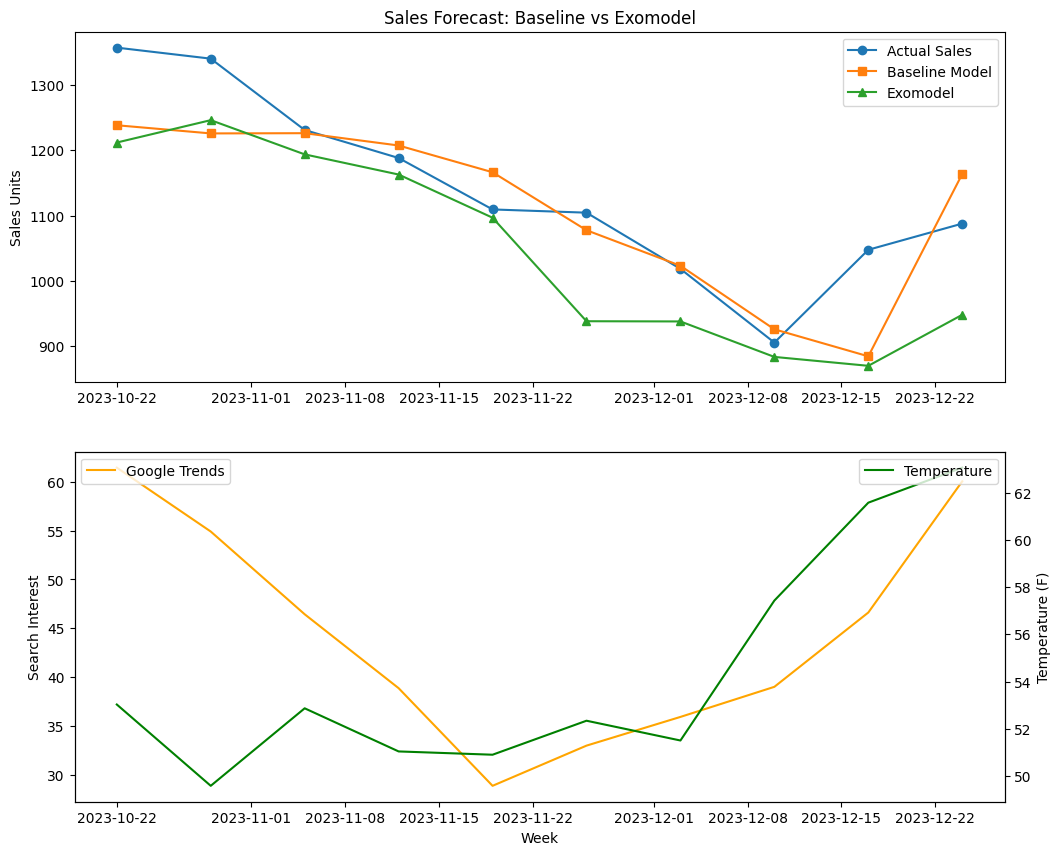

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Simulated weekly sneaker sales data
np.random.seed(42)
weeks = 52
dates = pd.date_range('2023-01-01', periods=weeks, freq='W')
baseline_sales = 1000 + np.sin(np.arange(weeks) * 2 * np.pi / 13) * 200  # Quarterly seasonality
trend = np.linspace(0, 200, weeks)
sales = baseline_sales + trend + np.random.normal(0, 50, weeks)

# Simulated Google Trends data (search interest)
google_trends = 50 + np.sin(np.arange(weeks) * 2 * np.pi / 13) * 15 + \
                np.random.normal(0, 5, weeks)
# Add leading indicator: search spikes 2 weeks before sales
google_trends = np.roll(google_trends, -2)

# Weather data (hot weather boosts sales)
weather_temp = 70 + np.sin(np.arange(weeks) * 2 * np.pi / 26) * 20 + \
               np.random.normal(0, 3, weeks)

# Create DataFrame
df = pd.DataFrame({
    'week': dates,
    'sales': sales,
    'google_trends': google_trends,
    'weather_temp': weather_temp
})

# Lag features
for lag in [1, 2, 3]:
    df[f'sales_lag_{lag}'] = df['sales'].shift(lag)
    df[f'trends_lag_{lag}'] = df['google_trends'].shift(lag)

df.dropna(inplace=True)

# Train/test split
train_size = int(0.8 * len(df))
train = df.iloc[:train_size]
test = df.iloc[train_size:]

# Define features
feature_cols = ['google_trends', 'weather_temp'] + \
               [col for col in df.columns if 'lag' in col]

X_train = train[feature_cols]
y_train = train['sales']
X_test = test[feature_cols]
y_test = test['sales']

# Train models
baseline_model = RandomForestRegressor(n_estimators=100, random_state=42)
baseline_model.fit(X_train[['sales_lag_1', 'sales_lag_2', 'sales_lag_3']], y_train)

exomodel = RandomForestRegressor(n_estimators=100, random_state=42)
exomodel.fit(X_train, y_train)

# Predict
baseline_pred = baseline_model.predict(X_test[['sales_lag_1', 'sales_lag_2', 'sales_lag_3']])
exomodel_pred = exomodel.predict(X_test)

# Evaluate
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
exomodel_rmse = np.sqrt(mean_squared_error(y_test, exomodel_pred))

print(f"Baseline Model RMSE: {baseline_rmse:.1f}")
print(f"Exomodel RMSE: {exomodel_rmse:.1f}")
print(f"Improvement: {((baseline_rmse - exomodel_rmse) / baseline_rmse * 100):.1f}%")

# Feature importance
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': exomodel.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop External Features:")
print(importance.head())

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
# Sales and predictions
ax1.plot(test['week'], y_test, label='Actual Sales', marker='o')
ax1.plot(test['week'], baseline_pred, label='Baseline Model', marker='s')
ax1.plot(test['week'], exomodel_pred, label='Exomodel', marker='^')
ax1.set_title("Sales Forecast: Baseline vs Exomodel")
ax1.set_ylabel("Sales Units")
ax1.legend()

# External signals
ax2.plot(test['week'], test['google_trends'], label='Google Trends', color='orange')
ax2_twin = ax2.twinx()
ax2_twin.plot(test['week'], test['weather_temp'], label='Temperature', color='green')
ax2.set_xlabel("Week")
ax2.set_ylabel("Search Interest")
ax2_twin.set_ylabel("Temperature (F)")
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')
plt.show()

# 10. Blockchain-Enabled Forecasting (The Future)


Blockchain Demand Forecasts:
sensor_a: 122 units/week next 2 weeks
  NO ACTION: Below safety threshold
circuit_b: 328 units/week next 2 weeks
  TRIGGER: Auto-order 1310 units (4-week buffer)
casing_c: 137 units/week next 2 weeks
  NO ACTION: Below safety threshold

Blockchain length: 31 blocks
Last block hash: 4bdf793ef599c21b...
Data is tamper-proof: any change alters the hash chain


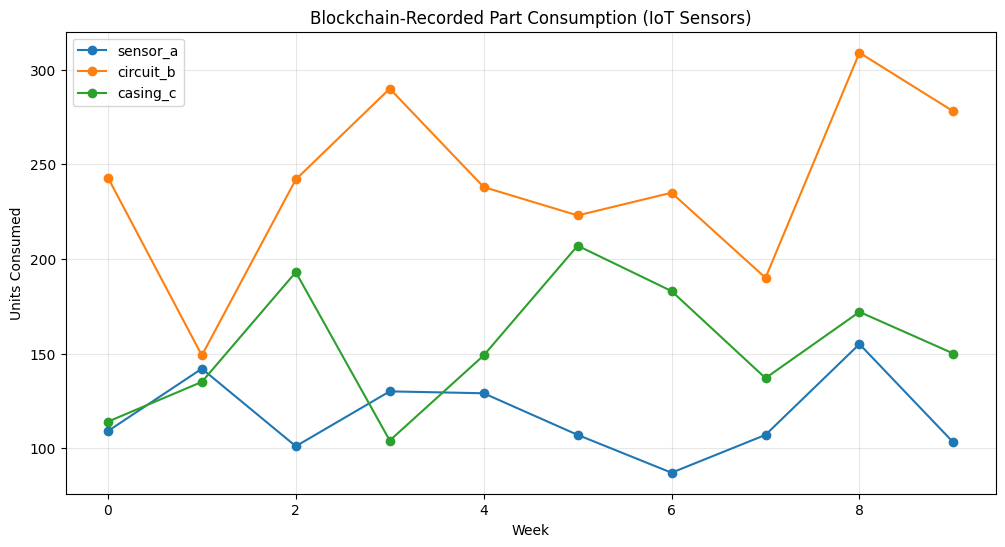

In [9]:
import hashlib
import json
import time
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

# Simulate blockchain block structure
class Block:
    def __init__(self, index, timestamp, data, previous_hash):
        self.index = index
        self.timestamp = timestamp
        self.data = data
        self.previous_hash = previous_hash
        self.hash = self.calculate_hash()

    def calculate_hash(self):
        block_string = json.dumps({
            "index": self.index,
            "timestamp": self.timestamp,
            "data": self.data,
            "previous_hash": self.previous_hash
        }, sort_keys=True)
        return hashlib.sha256(block_string.encode()).hexdigest()

# Simulate IoT sensors on factory floor detecting part consumption
class BlockchainForecast:
    def __init__(self):
        self.chain = [self.create_genesis_block()]
        self.part_consumption = {}

    def create_genesis_block(self):
        return Block(0, str(datetime.now()), {"message": "Genesis"}, "0")

    def add_block(self, data):
        previous_block = self.chain[-1]
        new_block = Block(
            index=len(self.chain),
            timestamp=str(datetime.now()),
            data=data,
            previous_hash=previous_block.hash
        )
        self.chain.append(new_block)
        return new_block

    def record_consumption(self, part_id, quantity, location):
        """IoT sensor records part usage immutably"""
        data = {
            "type": "consumption",
            "part_id": part_id,
            "quantity": quantity,
            "location": location,
            "timestamp": time.time()
        }
        self.add_block(data)

        # Track running total
        if part_id not in self.part_consumption:
            self.part_consumption[part_id] = []
        self.part_consumption[part_id].append(quantity)

    def get_forecast(self, part_id, lookback_weeks=4):
        """Generate demand forecast from blockchain data"""
        if part_id not in self.part_consumption:
            return None

        consumption = self.part_consumption[part_id]
        if len(consumption) < lookback_weeks:
            return np.mean(consumption) if consumption else 0

        # Simple trending forecast
        recent = consumption[-lookback_weeks:]
        trend = np.polyfit(range(len(recent)), recent, 1)[0]
        forecast = recent[-1] + trend * 2  # 2 weeks ahead

        return max(0, forecast)

# Simulate 10 weeks of production
blockchain = BlockchainForecast()
parts = ['sensor_a', 'circuit_b', 'casing_c']
np.random.seed(42)

for week in range(10):
    for part in parts:
        # Simulate varying consumption
        base_rate = {'sensor_a': 100, 'circuit_b': 250, 'casing_c': 150}[part]
        consumption = max(0, int(base_rate + np.random.normal(0, base_rate * 0.2)))
        blockchain.record_consumption(part, consumption, f"line_{np.random.randint(1,4)}")

# Generate forecasts and trigger smart contract logic
print("Blockchain Demand Forecasts:")
forecasts = {}
for part in parts:
    forecast = blockchain.get_forecast(part)
    forecasts[part] = forecast
    print(f"{part}: {forecast:.0f} units/week next 2 weeks")

    # Smart contract logic: auto-order if forecast > safety stock
    safety_stock = {'sensor_a': 150, 'circuit_b': 300, 'casing_c': 200}[part]
    if forecast > safety_stock:
        print(f"  TRIGGER: Auto-order {int(forecast * 4)} units (4-week buffer)")
    else:
        print(f"  NO ACTION: Below safety threshold")

# Verify immutability
print(f"\nBlockchain length: {len(blockchain.chain)} blocks")
print(f"Last block hash: {blockchain.chain[-1].hash[:16]}...")
print("Data is tamper-proof: any change alters the hash chain")

# Plot consumption history
consumption_df = pd.DataFrame(blockchain.part_consumption)
consumption_df.plot(marker='o', figsize=(12, 6))
plt.title("Blockchain-Recorded Part Consumption (IoT Sensors)")
plt.xlabel("Week")
plt.ylabel("Units Consumed")
plt.grid(True, alpha=0.3)
plt.show()